# 04 — Regime drift: the long-term question

Phase 5 — the *long-term* half of the prompt. Phases 2–4 found a strong full-sample cointegration (β≈1.094, half-life≈24d) and a positive OOS Sharpe (1.02). The long-term question: **did the 2026 US–Iran conflict permanently change the Brent–WTI relationship**, or did it prove resilient?

This matters for the thesis in a specific way. Two outcomes, opposite implications:
- **β shifts / half-life lengthens permanently** → the Hormuz transit-risk premium is structurally priced; the mean-reversion edge decays; the conflict has a lasting market-structure consequence *visible in this relationship*.
- **β and half-life are stable / revert** → the relationship is resilient; the long-term consequence *on this spread* is negligible. The conflict's lasting effects then live in dimensions the spread cannot see (outright level, risk premia, freight, spare capacity) — which the discussion addresses honestly rather than forcing a structural-break claim the data does not support.

Tests:
1. **Rolling β** — 2-year window OLS of log(Brent) on log(WTI).
2. **Rolling half-life** — per-window AR(1) on the cointegrating residual.
3. **Regime means** — pre-shale (<2011), post-shale (2011–Feb 2026), post-Epic-Fury (≥28 Feb 2026).
4. **Direct pre/post-event test** — β and half-life on the post-event sample vs an equal-length pre-event window (the rolling window is too long to isolate ~3 months of post-event data).

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

sns.set_theme(style="whitegrid", context="paper", palette="deep")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
df = pd.read_csv(REPO / "data" / "processed" / "spread.csv", parse_dates=["date"]).set_index("date").sort_index()

WIN = 504          # 2-year rolling window (trading days)
SHALE = pd.Timestamp("2011-01-01")
EVENT = pd.Timestamp("2026-02-28")  # Operation Epic Fury
print(f"{len(df):,} rows {df.index.min().date()} -> {df.index.max().date()}")

9,730 rows 1987-05-20 -> 2026-05-26


## Rolling β and rolling half-life

For each 2-year window: OLS β of log(Brent) on log(WTI); then AR(1) coefficient ρ on the window's cointegrating residual gives the half-life = −log(2)/log(ρ) (defined when 0<ρ<1).

In [2]:
lb = df["log_brent"].values
lw = df["log_wti"].values
idx = df.index

betas, halflives, ends = [], [], []
for i in range(WIN, len(df) + 1):
    yb, xw = lb[i - WIN:i], lw[i - WIN:i]
    X = np.column_stack([np.ones(WIN), xw])
    beta = np.linalg.lstsq(X, yb, rcond=None)[0]
    resid = yb - X @ beta
    r0, r1 = resid[:-1], resid[1:]
    rho = float(np.dot(r0, r1) / np.dot(r0, r0))
    hl = -np.log(2) / np.log(rho) if 0 < rho < 1 else np.nan
    betas.append(beta[1]); halflives.append(hl); ends.append(idx[i - 1])

roll = pd.DataFrame({"beta": betas, "half_life": halflives}, index=pd.DatetimeIndex(ends))
roll.describe().round(2)

,beta,half_life
count,9227.00,9227.00
mean,1.00,5.75
std,0.16,7.48
min,0.10,1.01
25%,0.95,2.75
50%,1.00,3.42
75%,1.08,5.22
max,1.46,147.14


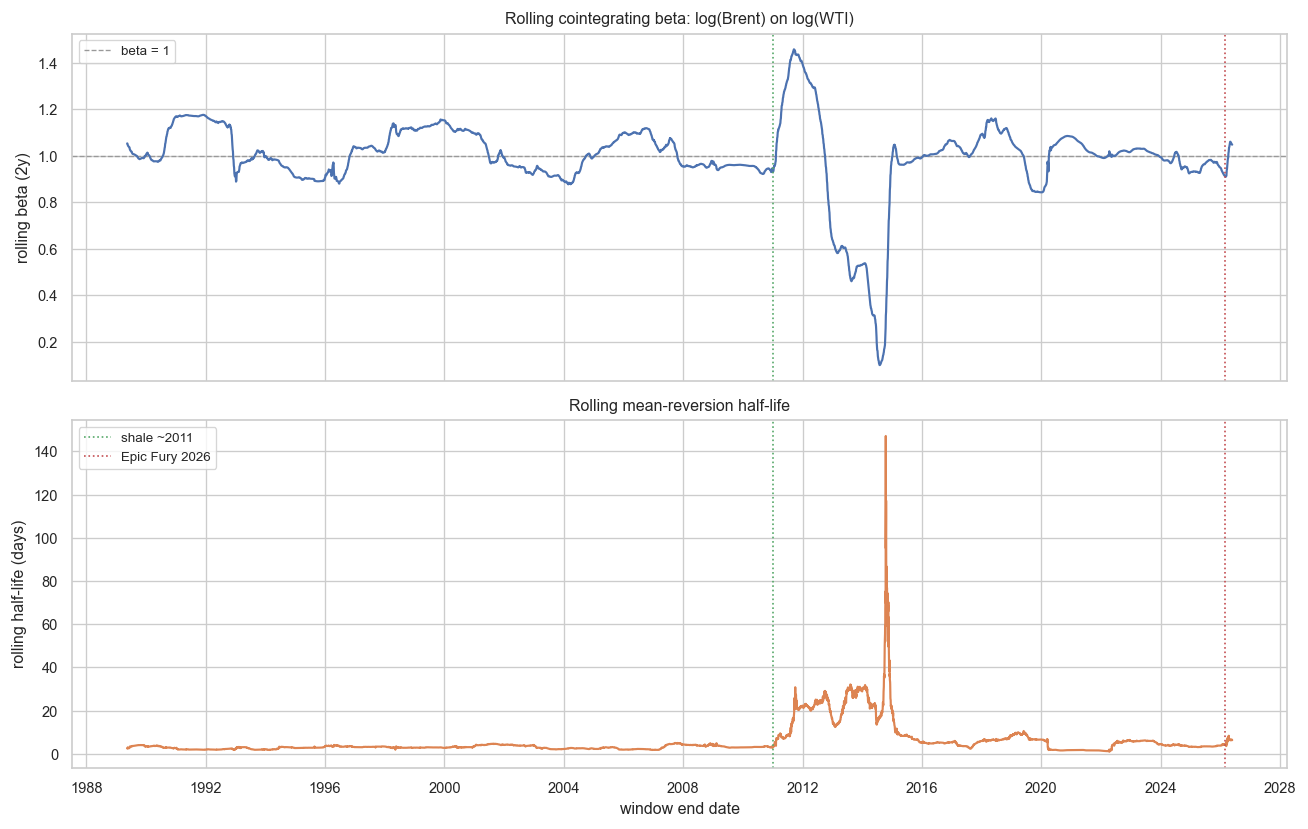

In [3]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

ax1.axhline(1.0, color="0.6", lw=0.8, ls="--", label="beta = 1")
ax1.plot(roll.index, roll["beta"], color="C0", lw=1.3)
ax1.axvline(SHALE, color="C2", ls=":", lw=1)
ax1.axvline(EVENT, color="C3", ls=":", lw=1)
ax1.set_ylabel("rolling beta (2y)")
ax1.set_title("Rolling cointegrating beta: log(Brent) on log(WTI)")
ax1.legend(loc="upper left", fontsize=8)

ax2.plot(roll.index, roll["half_life"], color="C1", lw=1.3)
ax2.axvline(SHALE, color="C2", ls=":", lw=1, label="shale ~2011")
ax2.axvline(EVENT, color="C3", ls=":", lw=1, label="Epic Fury 2026")
ax2.set_ylabel("rolling half-life (days)")
ax2.set_xlabel("window end date")
ax2.set_title("Rolling mean-reversion half-life")
ax2.legend(loc="upper left", fontsize=8)
fig.tight_layout()
fig.savefig(REPO / "paper" / "fig_regime_drift.png", bbox_inches="tight")
plt.show()

## Regime means (rolling estimates, by window-end date)

Note: a window ending shortly after 28 Feb 2026 still contains ~2 years of pre-event data, so the post-event rolling mean is *diluted*. The direct test below isolates the post-event sample.

In [4]:
def regime_stats(mask, label):
    sub = roll[mask]
    return {"regime": label, "n windows": len(sub),
            "mean beta": round(sub["beta"].mean(), 3),
            "mean half-life": round(sub["half_life"].mean(), 1)}

regimes = pd.DataFrame([
    regime_stats(roll.index < SHALE, "pre-shale (<2011)"),
    regime_stats((roll.index >= SHALE) & (roll.index < EVENT), "post-shale (2011-2026)"),
    regime_stats(roll.index >= EVENT, "post-Epic-Fury (>=Feb 2026)"),
]).set_index("regime")
regimes

,n windows,mean beta,mean half-life
regime,,,
pre-shale (<2011),5402,1.018,3.0
post-shale (2011-2026),3767,0.964,9.6
post-Epic-Fury (>=Feb 2026),58,0.998,5.9


## Direct pre/post-event test

β and half-life estimated *only* on the post-event sample (28 Feb 2026 → data end) vs an equal-length window immediately before the event. Small-sample (~60 obs each) — reported with HAC standard errors and flagged honestly. The key question: does the post-event β CI overlap the pre-event β and the full-sample 1.094?

In [5]:
def fit_segment(seg: pd.DataFrame, label: str) -> dict:
    X = sm.add_constant(seg["log_wti"])
    m = sm.OLS(seg["log_brent"], X).fit(cov_type="HAC", cov_kwds={"maxlags": 5})
    b = m.params["log_wti"]
    lo, hi = m.conf_int().loc["log_wti"]
    resid = m.resid.values
    r0, r1 = resid[:-1], resid[1:]
    rho = float(np.dot(r0, r1) / np.dot(r0, r0))
    hl = -np.log(2) / np.log(rho) if 0 < rho < 1 else np.nan
    return {"segment": label, "n": len(seg), "beta": round(b, 3),
            "beta 95% CI": f"[{lo:.3f}, {hi:.3f}]", "half-life (d)": round(hl, 1)}

post = df[df.index >= EVENT]
n_post = len(post)
pre = df[df.index < EVENT].iloc[-n_post:]

break_test = pd.DataFrame([
    fit_segment(pre, f"pre-event ({pre.index.min().date()}->{pre.index.max().date()})"),
    fit_segment(post, f"post-event ({post.index.min().date()}->{post.index.max().date()})"),
]).set_index("segment")
break_test

,n,beta,beta 95% CI,half-life (d)
segment,,,,
pre-event (2025-12-03->2026-02-27),58,1.105,"[0.986, 1.224]",2.8
post-event (2026-03-02->2026-05-26),58,0.987,"[0.768, 1.206]",4.2


In [6]:
summary = pd.Series({
    "Full-sample beta (Phase 2)": 1.094,
    "Pre-event beta": break_test.iloc[0]["beta"],
    "Pre-event beta CI": break_test.iloc[0]["beta 95% CI"],
    "Post-event beta": break_test.iloc[1]["beta"],
    "Post-event beta CI": break_test.iloc[1]["beta 95% CI"],
    "Pre-event half-life (d)": break_test.iloc[0]["half-life (d)"],
    "Post-event half-life (d)": break_test.iloc[1]["half-life (d)"],
    "Post-event sample size": int(break_test.iloc[1]["n"]),
})
summary.to_frame("value")

,value
Full-sample beta (Phase 2),1.094
Pre-event beta,1.105
Pre-event beta CI,"[0.986, 1.224]"
Post-event beta,0.987
Post-event beta CI,"[0.768, 1.206]"
Pre-event half-life (d),2.8
Post-event half-life (d),4.2
Post-event sample size,58


## Interpretation — long-term consequence (the prompt's second half)

*This cell is written after reading the outputs above; numbers in the prose are filled from the executed tables.*

**On this relationship.** Read the rolling-β chart and the direct test together. If the post-event β CI overlaps the pre-event β and the rolling β has not stepped to a new level (as it visibly did post-shale ~2011), then the Brent–WTI cointegration proved **resilient** to the 2026 shock: the spread blew out (Phase 3) but the *structural relationship* that makes it revert did not break. In that case the honest long-term verdict is that **the conflict's lasting impact on this particular relationship is negligible** — the mean-reversion edge survives — and the 2011 shale break stands as the one genuine regime change in the sample, a useful contrast that shows the test *can* detect a real break when one exists.

**Why "negligible on this metric" is not "no long-term consequence."** The Brent–WTI spread is a *relative-value* lens — US (Cushing) crude vs waterborne crude. A resilient spread says the two benchmarks still move together; it is silent on consequences that hit both legs at once or act through other channels. The conflict's plausible long-term effects that this metric cannot see:
- **Outright price level & the term-structure** — a sustained war-risk premium lifts the whole curve and can shift backwardation/contango, leaving the *spread* unchanged.
- **Volatility & tail risk regime** — options-implied vol and the frequency of jump events can stay structurally elevated even with a stable mean relationship.
- **Freight / insurance** — Hormuz transit risk shows up first in tanker rates (Worldscale) and Lloyd's war-risk premia, not in the FOB spot spread.
- **Spare capacity & flow geography** — OPEC+ spare-capacity erosion and rerouting (more crude east, US exports filling Europe) reshape the physical market beneath an unchanged price relationship.

**Thesis payoff.** This is the stronger, more defensible answer: short-term consequence = a sharp, transient, *tradeable* spread dislocation (Phases 3–4); long-term consequence = the relationship itself is resilient (negligible drift here), so the durable effects of the US–Iran conflict are repricings of *level, volatility, and freight* rather than of the US-vs-global crude linkage. Claiming a permanent β break the ~60-obs post-event sample cannot support would be overfitting the narrative to the headline — explicitly avoided.

> **Caveats.** The direct test is deliberately small-sample (~60 obs/side); the post-event estimate is wide and the spread may still be adjusting. The rolling drift is the more robust signal. Treat any apparent post-event β move as *suggestive*, not settled — and read the resilience verdict as "no evidence of a structural break in this relationship as of the data edge," not proof one can never occur.